In [1]:
import pandas as pd

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("used_cars_messy.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe(include='all'))

Shape: (15661, 14)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  str    
 2   brand              15661 non-null  str    
 3   model              15661 non-null  str    
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  str    
 6   seller_type        15661 non-null  str    
 7   fuel_type          15661 non-null  str    
 8   transmission_type  15661 non-null  str    
 9   mileage            14376 non-null  str    
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), str(8)
memory usage: 1.7 MB
None

Describe:
          Unnamed: 0     car_name 

In [3]:
df.duplicated().sum()

np.int64(169)

In [4]:
df['brand'].unique()

<StringArray>
[        'Renault',          'Maruti',           'Honda',        'Mahindra',
         'Hyundai',            'Ford',            'Jeep',             'BMW',
          'Jaguar',           'Skoda',      'Volkswagen',            'Tata',
   'Mercedes-Benz',          'Datsun',            'Audi',           'Tata ',
           'Lexus',        'Hyundai ',          'Toyota',         'Maruti ',
       'Mahindra ',        ' Maruti ',            'BMW ',          'Nissan',
       ' Mahindra',      ' Mahindra ',          ' Honda',        ' Hyundai',
         ' Maruti',      'Land Rover', ' Mercedes-Benz ',            'Mini',
         ' Honda ',          ' Ford ',           'Volvo',         ' Toyota',
         'Porsche',          ' Tata ',    ' Volkswagen ',       ' Hyundai ',
             'Kia',              'MG',            ' BMW',           'Isuzu',
           ' Ford',           'Ford ',       ' Renault ',          'Honda ',
           ' Tata',  'Mercedes-Benz ',         'Toyota ',     

In [5]:
df['brand'].value_counts()

brand
Maruti         4950
Hyundai        2954
Honda          1475
Mahindra        998
Toyota          788
               ... 
 Land Rover       1
ISUZU             1
 MG               1
 ISUZU            1
Rolls-Royce       1
Name: count, Length: 80, dtype: int64

In [6]:
df['brand'].str.startswith(' ').sum()
df['brand'].str.endswith(' ').sum()

np.int64(250)

In [7]:
df['brand'].str.islower().value_counts()
df['brand'].str.isupper().value_counts()

brand
False    15197
True       464
Name: count, dtype: int64

In [8]:
df['brand'].str.len().value_counts()

brand
6     6017
7     3632
5     1873
4     1469
8     1107
10     678
3      459
13     329
9       51
2       18
11      12
15       6
12       5
14       5
Name: count, dtype: int64

In [9]:
df['brand_clean'] = df['brand'].str.strip().str.lower()

df[['brand','brand_clean']].drop_duplicates()

,brand,brand_clean
0,Renault,renault
1,Maruti,maruti
2,Honda,honda
3,Mahindra,mahindra
5,Hyundai,hyundai
...,...,...
12783,Land Rover,land rover
13041,ISUZU,isuzu
14666,MG,mg
14894,ISUZU,isuzu


In [10]:
df[df['brand'] != df['brand'].str.strip().str.lower()]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,brand_clean
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0,renault
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0,maruti
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0,honda
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0,mahindra
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0,mahindra
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0,maruti
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0,volkswagen
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0,maruti
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0,hyundai


Missing values : Mileage : 1285 (8.2%), Engine : 1869 (11.9%), max_power : 799 (5.1%), seats : 443 (2.8%), selling_price: 158 (1%)

Wrong data types:
   - mileage stored as text ("18 kmpl")
   - km_driven stored as text ("42000 kms")

Inconsistent formatting:
   - brand column has mixed case and extra spaces

Duplicate rows present

Outliers:
   - selling_price has extremely high values (up to 1e9)

Task 2 : Cleaned code

In [11]:
df = pd.read_csv("used_cars_messy.csv")

# 1. Drop rows with missing target
df = df.dropna(subset=['selling_price'])

# 2. Clean brand column
df['brand'] = df['brand'].str.strip().str.lower()

# 3. Convert mileage to numeric
df['mileage'] = df['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)

# 4. Convert km_driven to numeric
df['km_driven'] = df['km_driven'].str.extract(r'(\d+)').astype(float)

# 5. Impute missing values

# Numeric
num_cols = df.select_dtypes(include=['float64','int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Categorical
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 6. Remove duplicates
df = df.drop_duplicates()

print("Final shape:", df.shape)

Final shape: (15323, 14)


C:\Users\Dr.Ravichandran\AppData\Local\Temp\ipykernel_14964\1846430004.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Task 3 Baseline MAE

In [12]:
from sklearn.metrics import mean_absolute_error

# Mean prediction
mean_price = df['selling_price'].mean()

y_true = df['selling_price']
y_pred = [mean_price] * len(df)

mae = mean_absolute_error(y_true, y_pred)

print("Mean Selling Price:", mean_price)
print("Baseline MAE:", mae)

Mean Selling Price: 1036636.8120472493
Baseline MAE: 867428.7961695362


In [16]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(y=df['selling_price'])

plt.title("Box Plot of Selling Price")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [17]:
pip install seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 6.8 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.3 MB 5.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.3 MB 3.9 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.3 MB 3.6 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.3 MB 3.5 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.3 MB 3.6 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.3 MB 3.7 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 3.7 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 3.5 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 3.4 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 3.3 MB/s eta 0:00:01
   ----------------

In [19]:
!pip install matplotlib

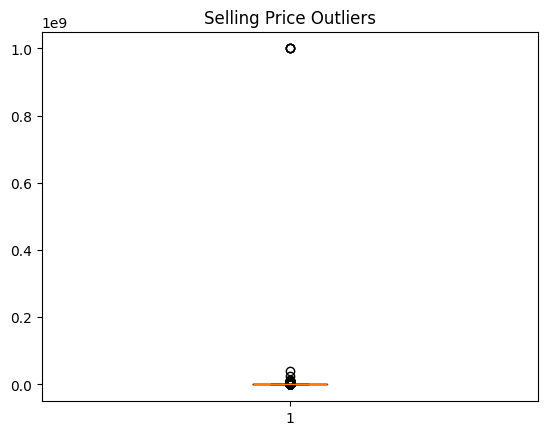

In [20]:
import matplotlib.pyplot as plt

plt.boxplot(df['selling_price'])
plt.title("Selling Price Outliers")
plt.show()

In [21]:
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-275000.0 1485000.0


In [22]:
df_clean = df[(df['selling_price'] >= lower_bound) & 
              (df['selling_price'] <= upper_bound)]

In [23]:
print("Before:", df.shape)
print("After:", df_clean.shape)

Before: (15323, 14)
After: (13931, 14)


In [25]:
from sklearn.metrics import mean_absolute_error

mean_price = df_clean['selling_price'].mean()

y_true = df_clean['selling_price']
y_pred = [mean_price] * len(df_clean)

mae = mean_absolute_error(y_true, y_pred)

print("New MAE:", mae)

New MAE: 219322.4281214302


In [37]:
new_mean = df_clean['selling_price'].mean()
print("New Average Selling Price:", new_mean)

print(round(new_mean, 2))


New Average Selling Price: 573016.0702749264
573016.07


In [29]:
original_mean = df['selling_price'].mean()

print("Original Mean:", original_mean)
print("New Mean (after removing outliers):", new_mean)

Original Mean: 1036636.8120472493
New Mean (after removing outliers): 573016.0702749264


In [38]:
median_price = df_clean['selling_price'].median()
print("Median Selling Price:", median_price)

Median Selling Price: 525000.0


After removing outliers using the IQR method, the average selling price was recalculated. When Median is estimated, it has further come down to 525000.
The revised median is more representative of the dataset as extreme values no longer skew the distribution.

In [ ]:
git init